# Paper screenshots

In [ ]:
import napari
from ome_zarr import OMEZarrMultiscale
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os

from napari_autoscape.focus_detector import (
    FocusLightningModel,
    preprocess_stack,
)
import matplotlib as mpl

c:\Users\johan\Documents\GitHub\autoSCAPE\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
viewer = napari.Viewer()
viewer.scale_bar.visible = True

In [55]:
output_dir = r"C:\Users\johan\Nextcloud_Gerbi\Documents\SCAPE_paper\manuscript\figures"

## LEICA: Top left wells overview 

In [5]:
viewer.layers.clear()
url = r"https://radosgw.public.os.wwu.de/methods-paper26/LEICA_plate1_overview_image.ome.zarr/"
layers = viewer.open(url, plugin="napari-ome-zarr", name="plate1_overview_image")

Root group {'ome': {'scene': {'coordinateTransformations': [{'type': 'translation', 'input': {'name': 'physical', 'path': 'A1'}, 'output': {'name': 'world'}, 'translation': [0.0028384652000001, 0.0057091052, 0.0074873634000000005]}, {'type': 'translation', 'input': {'name': 'physical', 'path': 'A10'}, 'output': {'name': 'world'}, 'translation': [0.0028384652000001, 0.0057091052, 0.0884873651]}, {'type': 'translation', 'input': {'name': 'physical', 'path': 'A11'}, 'output': {'name': 'world'}, 'translation': [0.0028384652000001, 0.0057091052, 0.0974873641]}, {'type': 'translation', 'input': {'name': 'physical', 'path': 'A12'}, 'output': {'name': 'world'}, 'translation': [0.0028384652000001, 0.0057091052, 0.10648736310000001]}, {'type': 'translation', 'input': {'name': 'physical', 'path': 'A2'}, 'output': {'name': 'world'}, 'translation': [0.0028384652000001, 0.0057091052, 0.0164873631]}, {'type': 'translation', 'input': {'name': 'physical', 'path': 'A3'}, 'output': {'name': 'world'}, 'tr

In [43]:
for layer in viewer.layers:
    layer.units = ("meter", "meter", "meter")

In [44]:
shapes_df = pd.read_csv(r"https://radosgw.public.os.wwu.de/methods-paper26/LEICA_plate1_overview_image.ome.zarr/detections.csv")
features = pd.read_csv(r"https://radosgw.public.os.wwu.de/methods-paper26/LEICA_plate1_overview_image.ome.zarr/detections_features.csv")

In [ ]:
shapes = []
for idx, group in shapes_df.groupby("index"):
    vertices = []
    for i in range(0, 4):
        vertices.append([float(group.iloc[i]["axis-0"]), float(group.iloc[i]["axis-1"]), float(group.iloc[i]["axis-2"])])
    shapes.append(vertices)

viewer.add_shapes(shapes, shape_type="rectangle",
                  face_color=[0,0,0,0],
                  edge_width = 0.00001,
                  features=features,
                  name='all_detections',
                  units=["meter", "meter", "meter"])

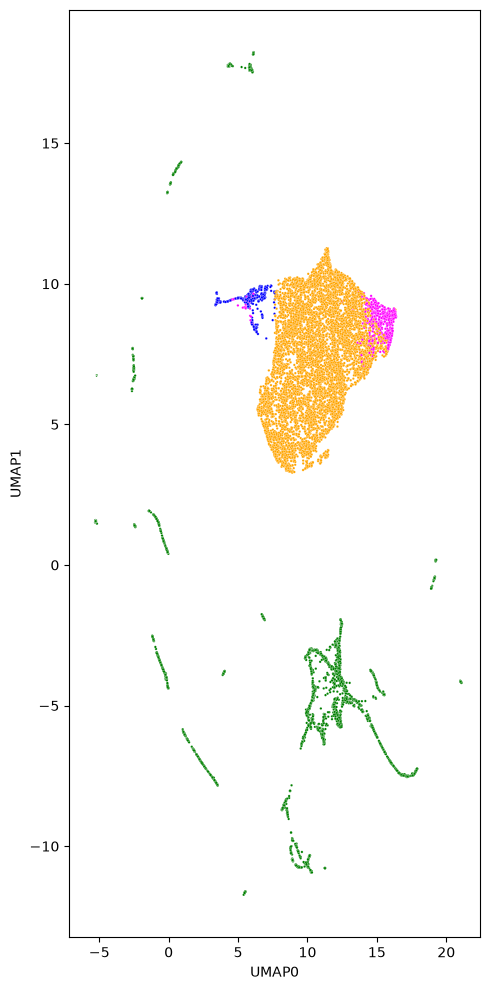

In [73]:
features = viewer.layers["all_detections"].features
fig, ax = plt.subplots(figsize=(5, 10))
sns.scatterplot(data=features, x="UMAP0", y="UMAP1", hue="MANUAL_CLUSTER_ID",
                palette={1: "orange", 2: "blue", 3: "green", 4: "magenta"}, 
                s=3, ax=ax, legend=False)

fig.tight_layout()
fig.savefig(os.path.join(output_dir, "interactive_selection_plot.png"), dpi=300, bbox_inches='tight')

In [ ]:
for layer in layers:
    layer.units = ["meter", "meter", "meter"]
    layer.colormap = 'gray'

viewer.camera.center = (0.0, 0.013279887557470239, 0.019623485680987186)
viewer.camera.zoom = 54447
viewer.window.resize(1891, 1024)
viewer.scale_bar.length = 2e-3
viewer.scale_bar.font_size = 0
viewer.layers[0].refresh()

_ = viewer.screenshot(os.path.join(output_dir, "figure_workflow", "plate1_overview_imageABC12.png"), flash=True, scale=None, canvas_only=True)

## LEICA: Single well overview

In [ ]:
viewer.camera.center = (0.0, 0.008874148504734183, 0.029661681198558824)
viewer.camera.zoom = 125750.70304928307
viewer.window.resize(1481, 1024)
viewer.cursor.position = (0.0029188365333333, 0.009609730919123836, 0.025979793462263197)
viewer.layers[0].refresh()

_ = viewer.screenshot(os.path.join(output_dir, "figure_workflow", "plate1_overview_imageA3.png"), flash=True, scale=None, canvas_only=True)

## ASI: Multiwell setup overview

In [18]:
viewer.layers.clear()

url = r"https://radosgw.public.os.wwu.de/methods-paper26/ASI_plate1_overview_image_20260826.ome.zarr/"
layer = viewer.open(url, plugin="napari-ome-zarr", name="plate1_overview_image")[0]

layer.colormap = "gray"
layer.contrast_limits = [1400, 45415]

detections_url = "https://radosgw.public.os.wwu.de/methods-paper26/ASI_plate1_overview_image_20260826.ome.zarr/detections.csv"
detections = pd.read_csv(detections_url)

features_url = r"https://radosgw.public.os.wwu.de/methods-paper26/ASI_plate1_overview_image_20260826.ome.zarr/detections_features.csv"
features = pd.read_csv(features_url)

rectangles = []
for i, rect in detections.groupby("index"):
    rectangles.append(rect[["axis-0", "axis-1", "axis-2"]].to_numpy())

norm = mpl.colors.Normalize(vmin=0, vmax=1, clip=True)
mapper = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.viridis)

colors = mapper.to_rgba(features["confidence"].values)

viewer.add_shapes(rectangles, units=["micrometer", "micrometer", "micrometer"], features=features, face_color=[0,0,0,0], edge_color=colors, edge_width=20)

viewer.dims.current_step = (25, 11366, 11366)
layer.locked_data_level = 4

viewer.scale_bar.length = 2e3
viewer.scale_bar.font_size = 0

viewer.window.set_geometry(266, 63, 1601, 1293)
viewer.camera.center = (0.0, 13186.395595285745, 6773.773485081039)
viewer.camera.zoom = 0.15912976624498962

_ = viewer.screenshot(os.path.join(output_dir, "figure_workflow", "plate1_overview_image_ASI_with_detections.png"), flash=True)


Root group {'ome': {'scene': {'coordinateTransformations': [{'type': 'translation', 'input': {'name': 'physical', 'path': '20260811_BF_W2_full_ImageStackFile_1'}, 'output': {'name': 'world'}, 'translation': [-53.199999999999996, 9486.38388, 2902.18062]}], 'coordinateSystems': [{'name': 'world', 'axes': [{'name': 'z', 'type': 'space', 'unit': 'micrometer'}, {'name': 'y', 'type': 'space', 'unit': 'micrometer'}, {'name': 'x', 'type': 'space', 'unit': 'micrometer'}]}]}, 'version': '0.6'}}


### Close-up

In [ ]:
viewer.camera.center = (0.0, 16180.921784520853, 6946.394038602467)
viewer.camera.zoom = 1.2900085563875534
layer.locked_data_level = None
viewer.scale_bar.length = 100
viewer.layers["rectangles"].edge_width = 10

INFO: Selected 273 shapes in this slice.


In [16]:
_ = viewer.screenshot(os.path.join(output_dir, "figure_workflow", "plate1_overview_image_ASI_with_detections_closeup.png"), flash=True)

## min intensity projection

In [ ]:
if "all_detections" in viewer.layers:
    viewer.layers.remove("all_detections")

#shapes_layer = viewer.open(r".\data\plate1\_detection\all_detections.csv", layer_type="shapes")[0]
shapes_df = pd.read_csv(r"https://radosgw.public.os.wwu.de/methods-paper26/LEICA_plate1_overview_image.ome.zarr/detections.csv")
features = pd.read_csv(r"https://radosgw.public.os.wwu.de/methods-paper26/LEICA_plate1_overview_image.ome.zarr/detections_features.csv")

shapes_layer.features = features
shapes_layer.edge_color = "confidence"
shapes_layer.edge_width = 10e-6
# shapes_layer.face_color = [0, 0, 0, 0]

colors = shapes_layer.edge_color
colors[:, -1] = 0.2
shapes_layer.face_color = colors

for _layer in viewer.layers:
    _layer.units = ["meter", "meter", "meter"]

viewer.camera.center = (0.0, 0.009549374404532449, 0.027152957878865014)
viewer.camera.zoom = 858351.0917355801
viewer.scale_bar.length = 5e-6

# shapes_layer.text = {
#         "string": '{confidence:0.2f}',
#         "anchor": "upper_left",
#         "size": 16,
#         "color": "white",
#         "translation":[0, 3*10e-6, 0]
        
#     }

viewer.scale_bar.length = 5e-4
viewer.scale_bar.font_size = 0
viewer.cursor.position = (0.0029054413111111, 0.010347687440923061, 0.027216022975566547)

viewer.scale_bar.font_size = 0
#_ = viewer.screenshot(os.path.join(output_dir, "figure_workflow", "plate1_overview_imageA3_with_detections.png"), flash=True, scale=None, canvas_only=True)

FileNotFoundError: Path '.\\data\\plate1\\_detection\\all_detections.csv' does not exist.

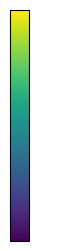

In [29]:
# create just a viridis colormap for the detections
fig, ax = plt.subplots(figsize=(0.25, 3))
norm = plt.Normalize(vmin=shapes_layer.features['confidence'].min(), vmax=shapes_layer.features['confidence'].max())
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
fig.colorbar(sm, cax=ax)

# make background transparent
fig.patch.set_alpha(0)

# make textcolor white
ax.yaxis.label.set_color('white')
ax.tick_params(axis='y', colors='white')

# save the figure
fig.savefig(os.path.join(output_dir, "figure_workflow", "plate1_overview_imageA3_with_detections_colormap.svg"), dpi=300, bbox_inches='tight', transparent=True)

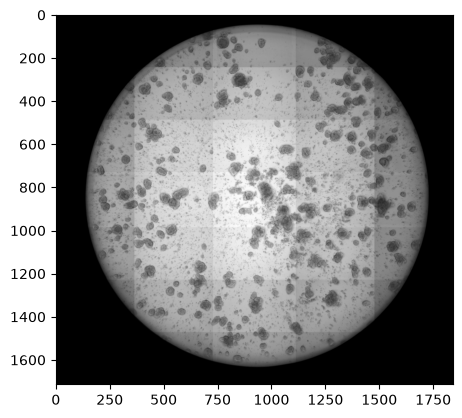

In [72]:
layer = viewer.layers["plate1_overview_image [5]"]
projection = layer.data[3].min(axis=0)
plt.imshow(projection, cmap="gray")


In [ ]:
viewer.camera.center = (0.0, 0.010600674604586708, 0.027634114858291498)
viewer.camera.zoom = 2589886.545521758

In [105]:
viewer.scale_bar.length = 50e-6
layer.refresh()

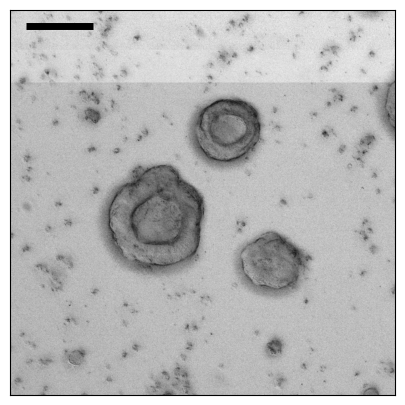

In [127]:
level = 0
factor = 3

projection = layer.data[level].min(axis=0)

fig, ax = plt.subplots(figsize=(5, 5))
left = 475 * 2**factor
right = 625 * 2**factor
top = 1200 * 2**factor
bottom = 1350 * 2**factor
ax.imshow(projection[top:bottom, left:right], cmap="gray")
ax.set_xticks([])
ax.set_yticks([])

# add scale bar
scale_bar_length = 100e-6  # 100 µm
scale_bar_pixel_length = scale_bar_length / layer.scale[1]
ax.hlines(50, 50, 50 + scale_bar_pixel_length, colors="black", linewidth=5)

fig.savefig(os.path.join(output_dir, "figure_workflow", "plate1_overview_imageA3_zoom.png"), dpi=300, bbox_inches="tight")

## Feature narrowing

In [5]:
# set all fontsizes to 8
plt.rcParams.update({'font.size': 6})


In [ ]:
viewer.layers.clear()
overview_layers = viewer.open(url, plugin="napari-ome-zarr", name="plate1_overview_image")
shapes_layer = viewer.open(r".\data\plate1\_detection\all_detections.csv", layer_type="shapes")[0]

shapes_layer.edge_width = 0.000005
shapes_layer.face_color = [0, 0, 0, 0]
shapes_layer.features = pd.read_csv(r".\data\plate1\_detection\all_detections_features.csv")

Root group {'ome': {'scene': {'coordinateTransformations': [{'type': 'translation', 'input': {'name': 'physical', 'path': 'A1'}, 'output': {'name': 'world'}, 'translation': [0.0028384652000001, 0.0057091052, 0.0074873634000000005]}, {'type': 'translation', 'input': {'name': 'physical', 'path': 'A10'}, 'output': {'name': 'world'}, 'translation': [0.0028384652000001, 0.0057091052, 0.0884873651]}, {'type': 'translation', 'input': {'name': 'physical', 'path': 'A11'}, 'output': {'name': 'world'}, 'translation': [0.0028384652000001, 0.0057091052, 0.0974873641]}, {'type': 'translation', 'input': {'name': 'physical', 'path': 'A12'}, 'output': {'name': 'world'}, 'translation': [0.0028384652000001, 0.0057091052, 0.10648736310000001]}, {'type': 'translation', 'input': {'name': 'physical', 'path': 'A2'}, 'output': {'name': 'world'}, 'translation': [0.0028384652000001, 0.0057091052, 0.0164873631]}, {'type': 'translation', 'input': {'name': 'physical', 'path': 'A3'}, 'output': {'name': 'world'}, 'tr

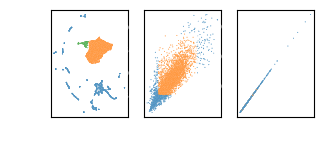

In [8]:
features = pd.read_csv(r".\data\plate1\_detection\all_detections_features.csv")
features1 = pd.read_csv(r".\data\plate1\_detection\step1\all_detections_features.csv")
features2 = pd.read_csv(r".\data\plate1\_detection\step2\all_detections_features.csv")

# change values 2 and 3 in MANUAL_CLUSTER_ID column to 3 and 2, respectively, in features dataframe
features['MANUAL_CLUSTER_ID'] = features['MANUAL_CLUSTER_ID'].replace({2: 3, 3: 2})

fig, axes = plt.subplots(ncols=3, figsize=(3.4, 1.4))
h = sns.scatterplot(data=features, x="UMAP0", y="UMAP1",
                    hue="MANUAL_CLUSTER_ID", palette="tab10",
                    marker="o", s=0.5, legend=False, ax=axes[0])
h1 = sns.scatterplot(data=features1, x="width", y="height",
                     hue="MANUAL_CLUSTER_ID", palette="tab10",
                     marker="o", s=0.5, legend=False, ax=axes[1])
h2 = sns.scatterplot(data=features2, x="nearest_box_distance", y="nearest_box_distance",
                     hue="MANUAL_CLUSTER_ID", palette="tab10",
                     marker="o", s=0.5, legend=False, ax=axes[2])

fig.patch.set_alpha(0)

# make text white
for ax in axes:
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.tick_params(axis='x', colors='white')
    ax.tick_params(axis='y', colors='white')

fig.savefig(os.path.join(output_dir, "figure_workflow", "umap_area.png"), dpi=300, bbox_inches='tight')

In [ ]:
features.columns

Index(['Unnamed: 0', 'area', 'mean_intensity', 'max_intensity',
       'min_intensity', 'std_intensity', 'x', 'y', 'width', 'height',
       'aspect_ratio', 'confidence', 'nearest_box_distance',
       'max_intersection_over_area', 'Well', 'Row', 'Column', 'UMAP0', 'UMAP1',
       'MANUAL_CLUSTER_ID'],
      dtype='str')

# Focus detection figures

In [3]:
viewer2 = napari.Viewer()

In [22]:
ms = OMEZarrMultiscale.from_ome_zarr("https://radosgw.public.os.wwu.de/methods-paper26/plate1_overview_image.ome.zarr/A1")
array = ms.images[1].data
pos = [5, 3316 // 2, 8161 // 2]
#pos = [5, 5394, 5303]
size = 128
sub = array[:, pos[1]-size:pos[1]+size, pos[2]-size:pos[2]+size]
sub

dask.array<getitem, shape=(9, 256, 256), dtype=uint16, chunksize=(9, 256, 144), chunktype=numpy.ndarray>

In [16]:
viewer2.scale_bar.length = 5e-5
viewer2.scale_bar.font_size = 0

In [17]:
viewer2.layers.clear()
viewer2.add_image(
  sub, scale=list(ms.images[1].scale.values()), name="sub", colormap="gray",
  blending="additive", units=["meter", "meter", "meter"], axis_labels=["z", "y", "x"])
viewer2.scale_bar.visible = True

In [19]:
_ = viewer2.export_figure(os.path.join(output_dir, "figure_workflow", "plate1_focus_detection_xy.png"), flash=True)

In [60]:
_ = viewer2.export_figure(os.path.join(output_dir, "figure_workflow", "plate1_focus_detection_zy.png"), flash=True)

In [21]:
best_model = FocusLightningModel.load_from_checkpoint(r"best.ckpt").eval()

In [24]:
crop = sub.compute().squeeze()
preprocessed_crop = preprocess_stack(crop)
for idx in range(crop.shape[0]):
    fig, ax = plt.subplots()
    ax.imshow(crop[idx], cmap="gray", vmin=crop.min(), vmax=crop.max())
    # no ticks
    ax.set_xticks([])
    ax.set_yticks([])

    name = f"plate1_focus_detection_crop_{idx:02d}.png"
    _ = fig.savefig(os.path.join(output_dir, "figure_workflow", name), dpi=300, bbox_inches='tight', transparent=True)

    plt.close(fig)
result = best_model(preprocessed_crop).detach().numpy().flatten()

c:\Users\johan\Documents\GitHub\autoSCAPE\.venv\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [26]:
from scipy.optimize import curve_fit
import numpy as np

def fit_func(x, a, x0, y0):
    return y0 + a  * (x-x0)**2

img_layer = viewer2.layers["sub"]
x = np.linspace(0, img_layer.data.shape[0] * img_layer.scale[0], num=img_layer.data.shape[0])
z_center = 4
params, cov = curve_fit(fit_func, x, result, bounds=([0, x.min(), -np.inf], [np.inf, x.max(), np.inf]), p0 = [400000000, x.max()/2, 0])

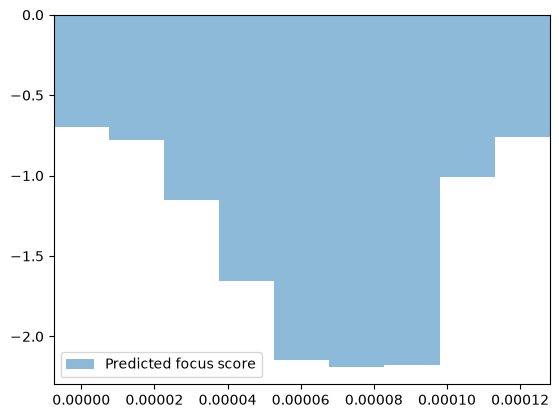

In [ ]:
x_plot = np.linspace(x.min(), x.max(), num=100)
#y_plot = -0.3 + 400000000 * (x_plot - 0.00295)**2
y_plot = fit_func(x_plot, *params)

bar_width = (x[1]-x[0])
fig, ax = plt.subplots()
ax.bar(x, result, width=(x[1]-x[0]), alpha=0.5, label="Predicted focus score")
ax.set_xlim(x.min() - bar_width/2, x.max() + bar_width/2)

ax.legend()

fig.savefig(os.path.join(output_dir, "figure_workflow", "plate1_focus_detection_focus_score.svg"), dpi=300, bbox_inches='tight', transparent=True)

## Training metrics

In [1]:
root = r"C:\Users\johan\Nextcloud_Gerbi\Documents\SCAPE_paper\data\figure_s1_training_metrics"

In [41]:
df_train_ASI = pd.read_csv(os.path.join(root, "train_focus_detector", "ASI", "lightning_logs_version_30_train.csv"))
df_val_ASI = pd.read_csv(os.path.join(root, "train_focus_detector", "ASI", "lightning_logs_version_30_val.csv"))
df_train_LEICA = pd.read_csv(os.path.join(root, "train_focus_detector", "LEICA", "lightning_logs_version_31_train.csv"))
df_val_LEICA = pd.read_csv(os.path.join(root, "train_focus_detector", "LEICA", "lightning_logs_version_31_val.csv"))

df_train_ASI.columns = ["Wall time", "Step", "train_loss_ASI"]
df_val_ASI.columns = ["Wall time", "Step", "val_loss_ASI"]
df_train_LEICA.columns = ["Wall time", "Step", "train_loss_LEICA"]
df_val_LEICA.columns = ["Wall time", "Step", "val_loss_LEICA"]

df_train_ASI["epoch"] = df_train_ASI.index
df_val_ASI["epoch"] = df_val_ASI.index
df_train_LEICA["epoch"] = df_train_LEICA.index
df_val_LEICA["epoch"] = df_val_LEICA.index

df = pd.merge(df_train_ASI, df_val_ASI, on=["Wall time", "Step", "epoch"], how="outer")
df = pd.merge(df, df_train_LEICA, on=["Wall time", "Step", "epoch"], how="outer")
df = pd.merge(df, df_val_LEICA, on=["Wall time", "Step", "epoch"], how="outer")
df.sort_values(by=["Step"], inplace=True)
df

,Wall time,Step,train_loss_ASI,epoch,val_loss_ASI,train_loss_LEICA,val_loss_LEICA
1,1.790286e+09,41,NaN,0,267.629364,NaN,NaN
3,1.790286e+09,41,71051.71875,0,NaN,NaN,NaN
0,1.790286e+09,45,NaN,0,NaN,NaN,546.247803
2,1.790286e+09,45,NaN,0,NaN,87954.445312,NaN
5,1.790286e+09,83,NaN,1,485.314056,NaN,NaN
...,...,...,...,...,...,...,...
249,1.790290e+09,3357,NaN,72,NaN,0.216837,NaN
250,1.790290e+09,3403,NaN,73,NaN,NaN,1.674180
251,1.790290e+09,3403,NaN,73,NaN,0.198127,NaN
252,1.790290e+09,3449,NaN,74,NaN,NaN,2.301562


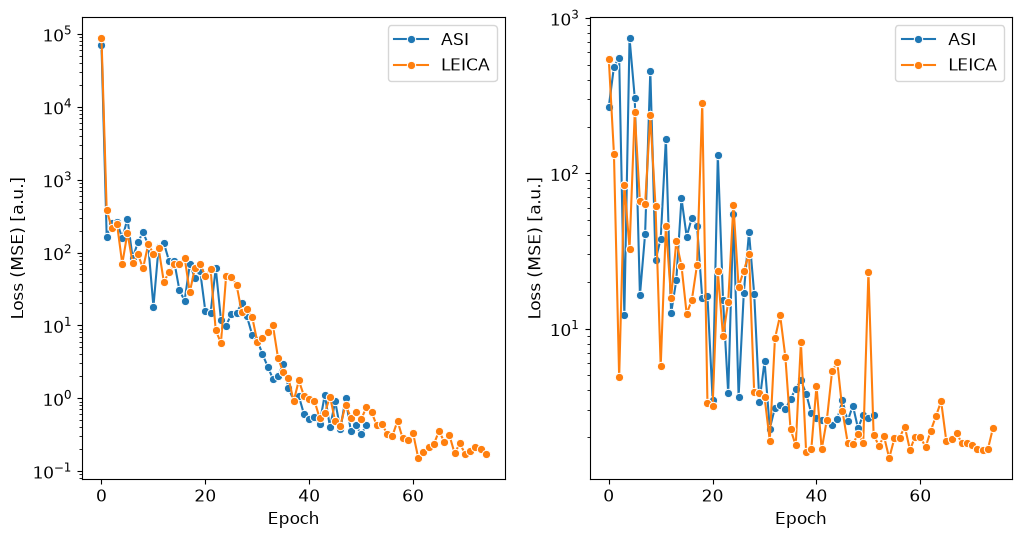

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

fontsize = 12

# # log scale on y
axes[0].set_yscale('log')
axes[1].set_yscale('log')

sns.lineplot(data=df, x="epoch", y="train_loss_ASI", ax=axes[0], label="ASI", marker="o", legend=False)
sns.lineplot(data=df, x="epoch", y="train_loss_LEICA", ax=axes[0], label="LEICA", marker="o", legend=False)
sns.lineplot(data=df, x="epoch", y="val_loss_ASI", ax=axes[1], label="ASI", marker="o", legend=False)
sns.lineplot(data=df, x="epoch", y="val_loss_LEICA", ax=axes[1], label="LEICA", marker="o", legend=False)

axes[0].set_ylabel("Loss (MSE) [a.u.]", fontsize=fontsize)
axes[1].set_ylabel("Loss (MSE) [a.u.]", fontsize=fontsize)
axes[0].set_xlabel("Epoch", fontsize=fontsize)
axes[1].set_xlabel("Epoch", fontsize=fontsize)

axes[0].legend(fontsize=fontsize)
axes[1].legend(fontsize=fontsize)

for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=fontsize)
    ax.tick_params(axis='both', which='minor', labelsize=fontsize)

fig.savefig(os.path.join(output_dir, "figure_training_metrics", "loss_plots.svg"), bbox_inches='tight')

## YOLO training metrics

In [59]:
df_yolo_ASI = pd.read_csv(os.path.join(root, "train-6_YOLO_ASI", "results.csv"))
df_yolo_LEICA = pd.read_csv(os.path.join(root, "train-11_YOLO_LEICA", "results.csv"))

In [66]:
df_yolo_ASI.head()

,epoch,time,train/box_loss,train/cls_loss,train/l1_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/l1_loss,lr/pg0,lr/pg1,lr/pg2
0,1,21.8203,2.14090,5.64643,0.01148,0.0,0.0,0.0,0.0,1.99173,6.66489,0.01396,0.002222,0.002222,0.080000
1,2,28.3880,2.08086,5.62276,0.01201,0.0,0.0,0.0,0.0,1.96272,6.62511,0.01381,0.005528,0.005528,0.049973
2,3,34.8872,2.11065,5.41579,0.01201,0.0,0.0,0.0,0.0,4.04822,8.17747,0.04235,0.008801,0.008801,0.019912
3,4,41.8067,2.64969,5.54238,0.01741,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.009851,0.009851,0.009851
4,5,52.1356,2.19471,4.54043,0.01346,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.009802,0.009802,0.009802


In [85]:
df_yolo_LEICA

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,14.0870,1.60340,5.03373,0.00649,0.00020,0.02273,0.00032,0.00025,1.48907,5.96152,0.00768,0.000000,0.000000,0.100000
1,2,17.3600,1.57783,4.70094,0.00730,0.00020,0.02273,0.00029,0.00021,1.51679,5.97565,0.00780,0.000100,0.000100,0.099099
2,3,20.8420,1.57194,4.88511,0.00649,0.00020,0.02273,0.00029,0.00023,1.49751,5.96753,0.00768,0.000198,0.000198,0.098198
3,4,24.3049,1.63468,5.04621,0.00691,0.00020,0.02273,0.00030,0.00024,1.48190,5.96489,0.00756,0.000296,0.000296,0.097295
4,5,27.9983,1.65632,4.55775,0.00708,0.00039,0.04545,0.00038,0.00019,1.48055,5.96424,0.00751,0.000392,0.000392,0.096392
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,196,678.4420,1.14173,0.49857,0.00498,0.85613,0.88636,0.91508,0.61592,1.28756,0.61662,0.00644,0.000347,0.000347,0.000347
196,197,681.2180,1.09916,0.49032,0.00547,0.86202,0.88636,0.91506,0.61908,1.29026,0.62556,0.00643,0.000298,0.000298,0.000298
197,198,684.0730,1.11293,0.44892,0.00534,0.86523,0.88636,0.91504,0.61733,1.29334,0.63195,0.00643,0.000249,0.000249,0.000249
198,199,686.8430,1.08082,0.43121,0.00508,0.86498,0.87372,0.91458,0.61051,1.29318,0.63757,0.00643,0.000199,0.000199,0.000199


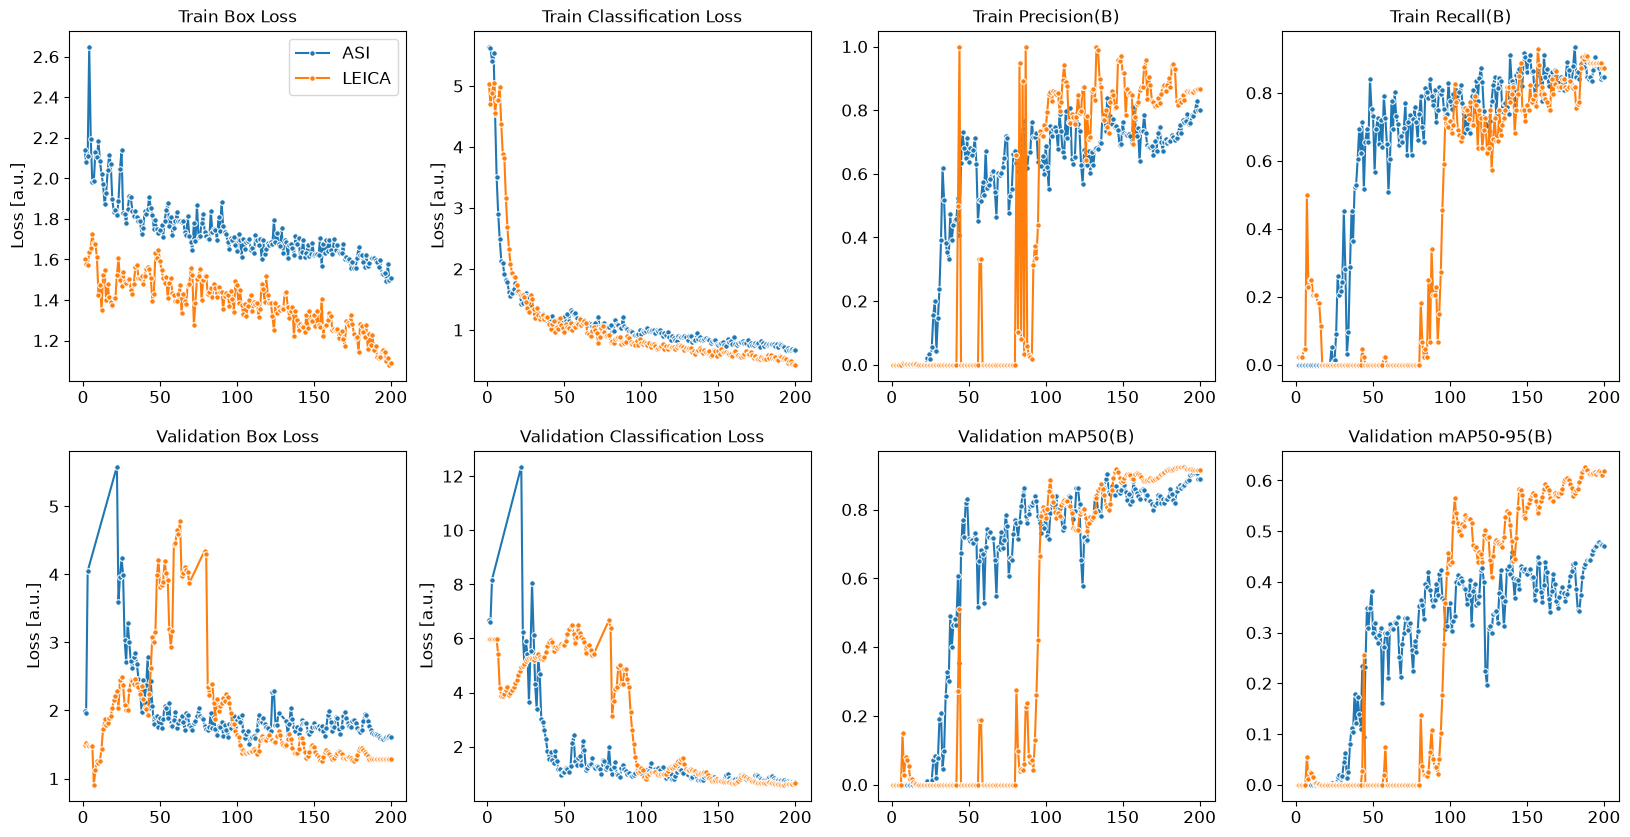

In [86]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

sns.lineplot(data=df_yolo_ASI, x="epoch", y="train/box_loss", ax=axes[0, 0], label="ASI", marker="o", legend=False, markersize=4)
sns.lineplot(data=df_yolo_LEICA, x="epoch", y="train/box_loss", ax=axes[0, 0], label="LEICA", marker="o", legend=False, markersize=4)
sns.lineplot(data=df_yolo_ASI, x="epoch", y="train/cls_loss", ax=axes[0, 1], label="ASI", marker="o", legend=False, markersize=4)
sns.lineplot(data=df_yolo_LEICA, x="epoch", y="train/cls_loss", ax=axes[0, 1], label="LEICA", marker="o", legend=False, markersize=4)
sns.lineplot(data=df_yolo_ASI, x="epoch", y="metrics/precision(B)", ax=axes[0, 2], label="ASI", marker="o", legend=False, markersize=4)
sns.lineplot(data=df_yolo_LEICA, x="epoch", y="metrics/precision(B)", ax=axes[0, 2], label="LEICA", marker="o", legend=False, markersize=4)
sns.lineplot(data=df_yolo_ASI, x="epoch", y="metrics/recall(B)", ax=axes[0, 3], label="ASI", marker="o", legend=False, markersize=4)
sns.lineplot(data=df_yolo_LEICA, x="epoch", y="metrics/recall(B)", ax=axes[0, 3], label="LEICA", marker="o", legend=False, markersize=4)

sns.lineplot(data=df_yolo_ASI, x="epoch", y="val/box_loss", ax=axes[1, 0], label="ASI", marker="o", legend=False, markersize=4)
sns.lineplot(data=df_yolo_LEICA, x="epoch", y="val/box_loss", ax=axes[1, 0], label="LEICA", marker="o", legend=False, markersize=4)
sns.lineplot(data=df_yolo_ASI, x="epoch", y="val/cls_loss", ax=axes[1, 1], label="ASI", marker="o", legend=False, markersize=4)
sns.lineplot(data=df_yolo_LEICA, x="epoch", y="val/cls_loss", ax=axes[1, 1], label="LEICA", marker="o", legend=False, markersize=4)
sns.lineplot(data=df_yolo_ASI, x="epoch", y="metrics/mAP50(B)", ax=axes[1, 2], label="ASI", marker="o", legend=False, markersize=4)
sns.lineplot(data=df_yolo_LEICA, x="epoch", y="metrics/mAP50(B)", ax=axes[1, 2], label="LEICA", marker="o", legend=False, markersize=4)
sns.lineplot(data=df_yolo_ASI, x="epoch", y="metrics/mAP50-95(B)", ax=axes[1, 3], label="ASI", marker="o", legend=False, markersize=4)
sns.lineplot(data=df_yolo_LEICA, x="epoch", y="metrics/mAP50-95(B)", ax=axes[1, 3], label="LEICA", marker="o", legend=False, markersize=4)

axes[0, 0].set_ylabel("Loss [a.u.]", fontsize=fontsize)
axes[0, 1].set_ylabel("Loss [a.u.]", fontsize=fontsize)
axes[0, 2].set_ylabel("")
axes[0, 3].set_ylabel("")
axes[1, 0].set_ylabel("Loss [a.u.]", fontsize=fontsize)
axes[1, 1].set_ylabel("Loss [a.u.]", fontsize=fontsize)
axes[1, 2].set_ylabel("")
axes[1, 3].set_ylabel("")

axes[0,0].set_title("Train Box Loss", fontsize=fontsize)
axes[0,1].set_title("Train Classification Loss", fontsize=fontsize)
axes[0,2].set_title("Train Precision(B)", fontsize=fontsize)
axes[0,3].set_title("Train Recall(B)", fontsize=fontsize)
axes[1,0].set_title("Validation Box Loss", fontsize=fontsize)
axes[1,1].set_title("Validation Classification Loss", fontsize=fontsize)
axes[1,2].set_title("Validation mAP50(B)", fontsize=fontsize)
axes[1,3].set_title("Validation mAP50-95(B)", fontsize=fontsize)

for ax in axes.flatten():
    ax.set_xlabel("", fontsize=fontsize)
    ax.tick_params(axis='both', which='major', labelsize=fontsize)

axes[0,0].legend(fontsize=fontsize)


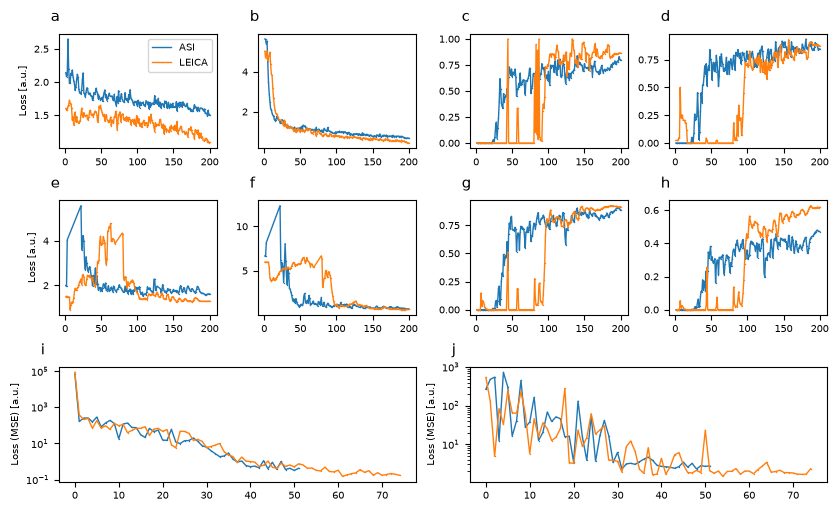

In [ ]:
fontsize_a4 = 7

# A4 width is 8.27 in; constrained_layout handles spacing for the spanning axes below
fig = plt.figure(figsize=(8.27, 5), constrained_layout=True)
gs = fig.add_gridspec(3, 4, height_ratios=[1, 1, 1], hspace=0.05)  # small vertical gap per row for subfigure letters

axes_yolo = [
    [fig.add_subplot(gs[0, c]) for c in range(4)],
    [fig.add_subplot(gs[1, c]) for c in range(4)],
]

ms = 1
line_kwargs = dict(marker="o", legend=False, markersize=ms, markeredgewidth=0, linewidth=1)

sns.lineplot(data=df_yolo_ASI, x="epoch", y="train/box_loss", ax=axes_yolo[0][0], label="ASI", **line_kwargs)
sns.lineplot(data=df_yolo_LEICA, x="epoch", y="train/box_loss", ax=axes_yolo[0][0], label="LEICA", **line_kwargs)
sns.lineplot(data=df_yolo_ASI, x="epoch", y="train/cls_loss", ax=axes_yolo[0][1], label="ASI", **line_kwargs)
sns.lineplot(data=df_yolo_LEICA, x="epoch", y="train/cls_loss", ax=axes_yolo[0][1], label="LEICA", **line_kwargs)
sns.lineplot(data=df_yolo_ASI, x="epoch", y="metrics/precision(B)", ax=axes_yolo[0][2], label="ASI", **line_kwargs)
sns.lineplot(data=df_yolo_LEICA, x="epoch", y="metrics/precision(B)", ax=axes_yolo[0][2], label="LEICA", **line_kwargs)
sns.lineplot(data=df_yolo_ASI, x="epoch", y="metrics/recall(B)", ax=axes_yolo[0][3], label="ASI", **line_kwargs)
sns.lineplot(data=df_yolo_LEICA, x="epoch", y="metrics/recall(B)", ax=axes_yolo[0][3], label="LEICA", **line_kwargs)

sns.lineplot(data=df_yolo_ASI, x="epoch", y="val/box_loss", ax=axes_yolo[1][0], label="ASI", **line_kwargs)
sns.lineplot(data=df_yolo_LEICA, x="epoch", y="val/box_loss", ax=axes_yolo[1][0], label="LEICA", **line_kwargs)
sns.lineplot(data=df_yolo_ASI, x="epoch", y="val/cls_loss", ax=axes_yolo[1][1], label="ASI", **line_kwargs)
sns.lineplot(data=df_yolo_LEICA, x="epoch", y="val/cls_loss", ax=axes_yolo[1][1], label="LEICA", **line_kwargs)
sns.lineplot(data=df_yolo_ASI, x="epoch", y="metrics/mAP50(B)", ax=axes_yolo[1][2], label="ASI", **line_kwargs)
sns.lineplot(data=df_yolo_LEICA, x="epoch", y="metrics/mAP50(B)", ax=axes_yolo[1][2], label="LEICA", **line_kwargs)
sns.lineplot(data=df_yolo_ASI, x="epoch", y="metrics/mAP50-95(B)", ax=axes_yolo[1][3], label="ASI", **line_kwargs)
sns.lineplot(data=df_yolo_LEICA, x="epoch", y="metrics/mAP50-95(B)", ax=axes_yolo[1][3], label="LEICA", **line_kwargs)

ax_train_loss = fig.add_subplot(gs[2, 0:2])
ax_val_loss = fig.add_subplot(gs[2, 2:4])

ax_train_loss.set_yscale('log')
ax_val_loss.set_yscale('log')

sns.lineplot(data=df, x="epoch", y="train_loss_ASI", ax=ax_train_loss, label="ASI", **line_kwargs)
sns.lineplot(data=df, x="epoch", y="train_loss_LEICA", ax=ax_train_loss, label="LEICA", **line_kwargs)
sns.lineplot(data=df, x="epoch", y="val_loss_ASI", ax=ax_val_loss, label="ASI", **line_kwargs)
sns.lineplot(data=df, x="epoch", y="val_loss_LEICA", ax=ax_val_loss, label="LEICA", **line_kwargs)

ax_train_loss.set_ylabel("Loss (MSE) [a.u.]", fontsize=fontsize_a4)
ax_val_loss.set_ylabel("Loss (MSE) [a.u.]", fontsize=fontsize_a4)
#ax_train_loss.set_title("Focus Detector: Train Loss", fontsize=fontsize_a4)
#ax_val_loss.set_title("Focus Detector: Validation Loss", fontsize=fontsize_a4)

axes_yolo[0][0].set_ylabel("Loss [a.u.]", fontsize=fontsize_a4)
axes_yolo[1][0].set_ylabel("Loss [a.u.]", fontsize=fontsize_a4)
for row, col in [(0, 1), (0, 2), (0, 3), (1, 1), (1, 2), (1, 3)]:
    axes_yolo[row][col].set_ylabel("")

titles = [
    ["Train Box Loss", "Train Cls Loss", "Train Precision(B)", "Train Recall(B)"],
    ["Val Box Loss", "Val Cls Loss", "Val mAP50(B)", "Val mAP50-95(B)"],
]
for row in range(2):
    for col in range(4):
        # axes_yolo[row][col].set_title(titles[row][col], fontsize=fontsize_a4)
        axes_yolo[row][col].set_xlabel("")
        axes_yolo[row][col].tick_params(axis='both', which='major', labelsize=fontsize_a4)

for ax in [ax_train_loss, ax_val_loss]:
    ax.set_xlabel("")
    ax.tick_params(axis='both', which='major', labelsize=fontsize_a4)

axes_yolo[0][0].legend(fontsize=fontsize_a4)  # only plot keeping a legend

subplot_letters = "abcdefghik"
ordered_axes = axes_yolo[0] + axes_yolo[1] + [ax_train_loss, ax_val_loss]
for ax, letter in zip(ordered_axes, subplot_letters):
    ax.text(-0.05, 1.08, letter, transform=ax.transAxes, fontsize=fontsize_a4 + 4, va="bottom", ha="left")

fig.savefig(os.path.join(output_dir, "figure_training_metrics", "combined_training_metrics_a4.svg"), bbox_inches='tight')
fig.savefig(os.path.join(output_dir, "figure_training_metrics", "combined_training_metrics_a4.png"), dpi=300, bbox_inches='tight')
